# MATH 210 Introduction to Mathematical Computing

**April 1, 2026**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

## General Interpolation

Consider the points: $(0,1),(\pi/2,3),(\pi,3/2)$. Choose an interpolant of the form: $f(x) = c_0 + c_1 \sin(x) + c_2 \cos(x)$. Find the coefficients of the interpolant.

In [8]:
x = np.array([0,np.pi/2,np.pi])
y = np.array([1.,2.,1.5])
A1 = np.column_stack([np.ones(3),np.sin(x),np.cos(x)])
print(A1)

[[ 1.0000000e+00  0.0000000e+00  1.0000000e+00]
 [ 1.0000000e+00  1.0000000e+00  6.1232340e-17]
 [ 1.0000000e+00  1.2246468e-16 -1.0000000e+00]]


In [9]:
c1 = la.solve(A1,y)
print(c1)

[ 1.25  0.75 -0.25]


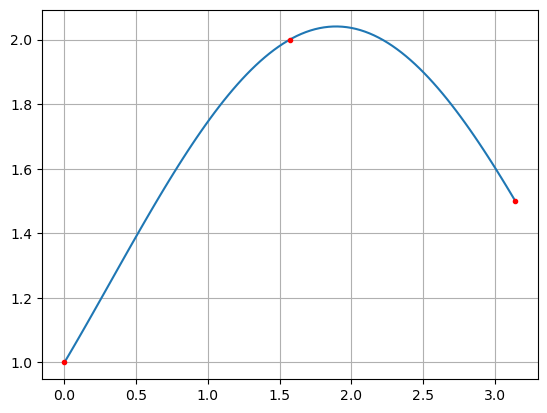

In [10]:
xs1 = np.linspace(0,np.pi,100)
ys1 = c1[0] + c1[1]*np.sin(xs1) + c1[2]*np.cos(xs1)
plt.plot(xs1,ys1,x,y,'r.'), plt.grid(True)
plt.show()

Now choose a different interpolant: $f(x) = c_0 + c_1 e^x + c_2 e^{-x}$. Compute the coefficients and compare.

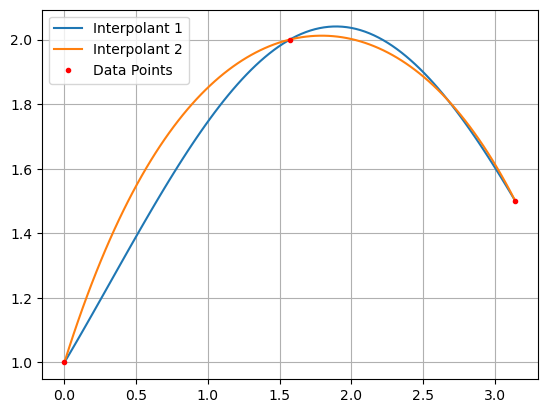

In [12]:
A2 = np.column_stack([np.ones(3),np.exp(x),np.exp(-x)])
c2 = la.solve(A2,y)
xs2 = np.linspace(0,np.pi,100)
ys2 = c2[0] + c2[1]*np.exp(xs2) + c2[2]*np.exp(-xs2)
plt.plot(xs1,ys1,xs2,ys2,x,y,'r.')
plt.legend(['Interpolant 1','Interpolant 2','Data Points']), plt.grid(True)
plt.show()

## Least Squares Data Fitting

Let's do an example with real data. The file `tidal_data.csv` is sea level measured at Vancouver airport.

In [13]:
import pandas as pd

In [14]:
data = pd.read_csv('tidal_data.csv')

Look at the top 5 rows:

In [15]:
data.head()

,Date,observations(m)
0,2022-06-07 12:54 PDT,2.94
1,2022-06-07 12:53 PDT,2.94
2,2022-06-07 12:52 PDT,2.95
3,2022-06-07 12:51 PDT,2.95
4,2022-06-07 12:50 PDT,2.95


In [16]:
data.tail()

,Date,observations(m)
10074,2022-05-31 13:00 PDT,0.66
10075,2022-05-31 12:59 PDT,0.66
10076,2022-05-31 12:58 PDT,0.66
10077,2022-05-31 12:57 PDT,0.66
10078,2022-05-31 12:56 PDT,0.66


The data is sea level (in meters) measured every minute for about week in 2022. Plot the data.

In [17]:
N = data.shape[0]
x = np.arange(N)
y = data.iloc[:,1].values

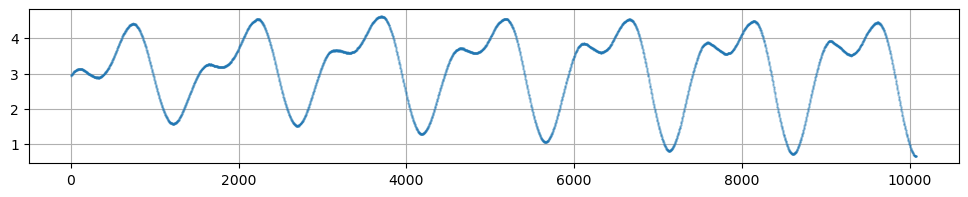

In [22]:
plt.figure(figsize=(12,2))
plt.plot(x,y,'.',ms=1,alpha=0.2), plt.grid(True)
plt.show()

Let's choose a model and find coefficients which best fit the data. Clearly we should choose periodic functions. Note that the functions

$$
\sin \left( \frac{2 \pi k x}{N} \right) \hspace{10mm} \cos \left( \frac{2 \pi k x}{N} \right)
$$

have $k$ periods for $x=0,\dots,N$. We see at least 2 patterns inthe data: something happening 7 times and another 14 times.

Therefore we choose $k=7$ and $k=14$ and construct the following model:

$$
f(x) = c_0 + c_1 \sin(14\pi x/N) + c_2 \cos(14 \pi x/N) + c_3 \sin(28 \pi x/N) + c_4 \cos(28 \pi x/N)
$$

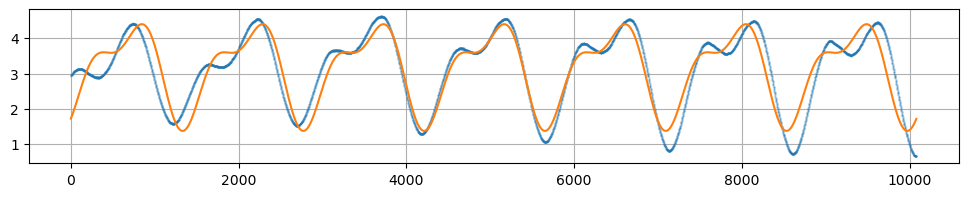

In [25]:
f0 = np.ones(N)
f1 = np.sin(14*np.pi*x/N)
f2 = np.cos(14*np.pi*x/N)
f3 = np.sin(28*np.pi*x/N)
f4 = np.cos(28*np.pi*x/N)
A = np.column_stack([f0,f1,f2,f3,f4])
c = la.solve(A.T@A,A.T@y)
fx = c[0] + c[1]*np.sin(14*np.pi*x/N) + c[2]*np.cos(14*np.pi*x/N) + c[3]*np.sin(28*np.pi*x/N) + c[4]*np.cos(28*np.pi*x/N)
plt.figure(figsize=(12,2))
plt.plot(x,y,'.',ms=1,alpha=0.2)
plt.plot(x,fx), plt.grid(True)
plt.show()

Not bad. How could we change the model for a better result?